In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_excel("state_economy_predictor_for_poverty_dataset.xlsx")

In [3]:
print(df.head())

           state    category  year  population  literacy_rate  \
0  Uttar Pradesh       Urban  2019   128021863          80.74   
1    Maharashtra       Rural  2016    99552376          67.52   
2      Karnataka       Urban  2023    56331368          57.80   
3          Bihar  Semi-Urban  2007   147905005          71.82   
4    West Bengal       Rural  2008    60804654          58.81   

   unemployment_rate  labour_participation_rate  healthcare_index  \
0               3.65                      45.93             38.49   
1              11.40                      45.30             52.53   
2              17.13                      76.69             83.50   
3               4.10                      68.70             60.51   
4               4.33                      41.72             54.52   

   inflation_rate  gdp_growth_rate  per_capita_income  poverty_rate  
0            9.80             8.01          480603.92          5.96  
1            5.30             6.56          482053.31 

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   state                      6000 non-null   object 
 1   category                   6000 non-null   object 
 2   year                       6000 non-null   int64  
 3   population                 6000 non-null   int64  
 4   literacy_rate              6000 non-null   float64
 5   unemployment_rate          6000 non-null   float64
 6   labour_participation_rate  6000 non-null   float64
 7   healthcare_index           6000 non-null   float64
 8   inflation_rate             6000 non-null   float64
 9   gdp_growth_rate            6000 non-null   float64
 10  per_capita_income          6000 non-null   float64
 11  poverty_rate               6000 non-null   float64
dtypes: float64(8), int64(2), object(2)
memory usage: 562.6+ KB
None


In [5]:
print(df.describe())

              year    population  literacy_rate  unemployment_rate  \
count  6000.000000  6.000000e+03    6000.000000        6000.000000   
mean   2014.451667  7.527539e+07      76.624887           9.484618   
std       5.738364  4.340911e+07      12.457024           4.906831   
min    2005.000000  5.499760e+05      55.010000           1.000000   
25%    2010.000000  3.750169e+07      65.860000           5.250000   
50%    2014.000000  7.569644e+07      76.710000           9.420000   
75%    2019.000000  1.125842e+08      87.452500          13.740000   
max    2024.000000  1.499768e+08      98.000000          18.000000   

       labour_participation_rate  healthcare_index  inflation_rate  \
count                6000.000000       6000.000000     6000.000000   
mean                   58.924085         64.753750        6.481465   
std                    10.935376         17.253324        2.608136   
min                    40.000000         35.000000        2.000000   
25%                

In [6]:
print(df.isnull().sum())

state                        0
category                     0
year                         0
population                   0
literacy_rate                0
unemployment_rate            0
labour_participation_rate    0
healthcare_index             0
inflation_rate               0
gdp_growth_rate              0
per_capita_income            0
poverty_rate                 0
dtype: int64


In [7]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['year', 'population', 'literacy_rate', 'unemployment_rate',
       'labour_participation_rate', 'healthcare_index', 'inflation_rate',
       'gdp_growth_rate', 'per_capita_income', 'poverty_rate'],
      dtype='object')

Categorical Columns:
Index(['state', 'category'], dtype='object')


In [8]:
num_imputer = SimpleImputer(strategy="mean")
df[num_cols] = num_imputer.fit_transform(df[num_cols])
print("Missing values handled successfully")

Missing values handled successfully


In [9]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   state  category    year   population  literacy_rate  unemployment_rate  \
0     18         2  2019.0  128021863.0          80.74               3.65   
1     12         0  2016.0   99552376.0          67.52              11.40   
2      9         2  2023.0   56331368.0          57.80              17.13   
3      2         1  2007.0  147905005.0          71.82               4.10   
4     19         0  2008.0   60804654.0          58.81               4.33   

   labour_participation_rate  healthcare_index  inflation_rate  \
0                      45.93             38.49            9.80   
1                      45.30             52.53            5.30   
2                      76.69             83.50            4.74   
3                      68.70             60.51            3.87   
4                      41.72             54.52            5.50   

   gdp_growth_rate  per_capita_income  poverty_rate  
0             8.01          480603.92          5.96  
1             6.56          4820

In [10]:
# Income and literacy interaction

df["income_literacy_interaction"] = (
    df["per_capita_income"] * df["literacy_rate"]
)

# Employment and healthcare interaction

df["employment_healthcare_score"] = (
    df["labour_participation_rate"] *
    df["healthcare_index"]
)

print(df.head())

   state  category    year   population  literacy_rate  unemployment_rate  \
0     18         2  2019.0  128021863.0          80.74               3.65   
1     12         0  2016.0   99552376.0          67.52              11.40   
2      9         2  2023.0   56331368.0          57.80              17.13   
3      2         1  2007.0  147905005.0          71.82               4.10   
4     19         0  2008.0   60804654.0          58.81               4.33   

   labour_participation_rate  healthcare_index  inflation_rate  \
0                      45.93             38.49            9.80   
1                      45.30             52.53            5.30   
2                      76.69             83.50            4.74   
3                      68.70             60.51            3.87   
4                      41.72             54.52            5.50   

   gdp_growth_rate  per_capita_income  poverty_rate  \
0             8.01          480603.92          5.96   
1             6.56          48

In [11]:
correlation_matrix = df.corr()
print(correlation_matrix["poverty_rate"].sort_values(ascending=False))

poverty_rate                   1.000000
unemployment_rate              0.637074
inflation_rate                 0.101887
gdp_growth_rate                0.007471
state                         -0.000938
category                      -0.004097
population                    -0.011674
year                          -0.020914
labour_participation_rate     -0.056152
healthcare_index              -0.111341
employment_healthcare_score   -0.121921
literacy_rate                 -0.363429
per_capita_income             -0.714196
income_literacy_interaction   -0.737236
Name: poverty_rate, dtype: float64


In [12]:
X = df.drop(columns=["poverty_rate"])

In [13]:
y = df["poverty_rate"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (4800, 13)
Testing Shape : (1200, 13)


In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully")

Linear Regression model trained successfully


In [16]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[ 4.55063747  6.02070625 37.88889795 27.46800724 33.4959824  22.65466653
  7.95385299 14.78700039 35.73674246 26.52226068]


In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 2.367769931181577
MSE : 9.050008226018395
RMSE: 3.008323158508473
R2 Score: 0.9332024274033678


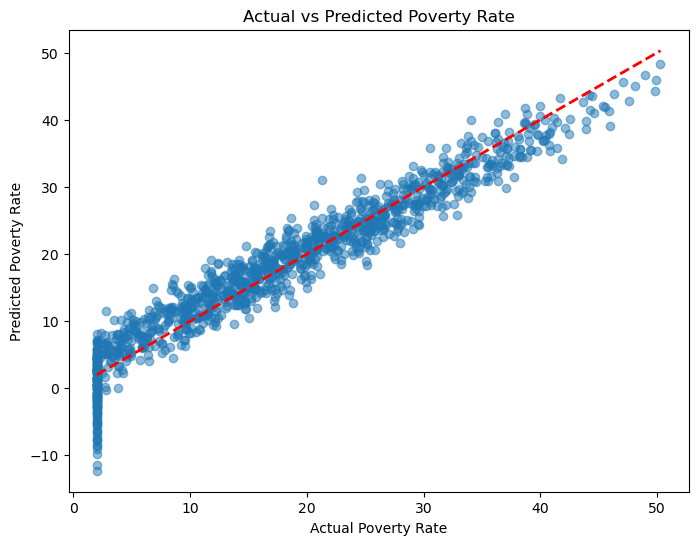

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Poverty Rate")
plt.ylabel("Predicted Poverty Rate")
plt.title("Actual vs Predicted Poverty Rate")

plt.show()

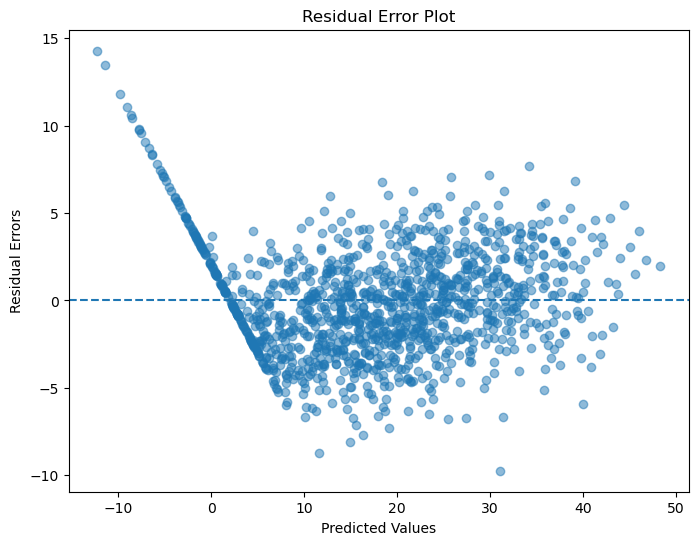

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Error Plot")

plt.show()

In [20]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(X_train_poly.shape)

(4800, 105)


In [21]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

print("Polynomial Regression model trained")

Polynomial Regression model trained


In [22]:
poly_pred = poly_model.predict(X_test_poly)
print(poly_pred[:10])

[ 6.23430547  5.62789686 38.44312482 26.88848401 37.19617621 21.66268977
  1.26547145 11.4115297  36.10098201 30.61152703]


In [23]:
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_pred)

print("Polynomial MAE :", poly_mae)
print("Polynomial MSE :", poly_mse)
print("Polynomial RMSE:", poly_rmse)
print("Polynomial R2  :", poly_r2)

Polynomial MAE : 2.7089850468798984
Polynomial MSE : 11.793050385323893
Polynomial RMSE: 3.43410110295604
Polynomial R2  : 0.9129561963286758


In [24]:
# Calculate range of target variable

target_range = y.max() - y.min()

# Calculate Normalized RMSE

nrmse = rmse / target_range

print("Target Range :", target_range)
print("Normalized RMSE :", nrmse)
print("Normalized RMSE Percentage :", nrmse * 100)

Target Range : 55.02
Normalized RMSE : 0.05467690219026668
Normalized RMSE Percentage : 5.467690219026668


In [25]:
# Calculate target range

target_range = y.max() - y.min()

# Normalized Metrics

nmae = mae / target_range
nmse = mse / (target_range ** 2)
nrmse = rmse / target_range

# Print Results

print("Target Range :", target_range)
print("\nNormalized MAE :", nmae)
print("Normalized MSE :", nmse)
print("Normalized RMSE:", nrmse)
print("\nNormalized MAE Percentage :", nmae * 100)
print("Normalized RMSE Percentage:", nrmse * 100)

Target Range : 55.02

Normalized MAE : 0.04303471339842924
Normalized MSE : 0.0029895636331239896
Normalized RMSE: 0.05467690219026668

Normalized MAE Percentage : 4.3034713398429245
Normalized RMSE Percentage: 5.467690219026668


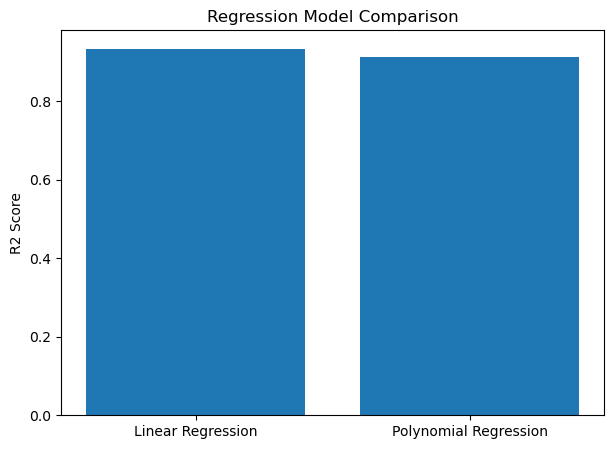

In [26]:
models = [
    "Linear Regression",
    "Polynomial Regression"
]

scores = [
    r2,
    poly_r2
]

plt.figure(figsize=(7,5))
plt.bar(models, scores)

plt.ylabel("R2 Score")
plt.title("Regression Model Comparison")

plt.show()

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance)

                        Feature   Coefficient
5             unemployment_rate  1.428789e+00
8                inflation_rate  4.729665e-01
0                         state  7.021555e-03
12  employment_healthcare_score  2.014340e-05
11  income_literacy_interaction  5.495046e-07
3                    population  9.451642e-10
10            per_capita_income -1.048151e-04
9               gdp_growth_rate -2.684408e-03
2                          year -3.714784e-03
6     labour_participation_rate -8.028273e-03
1                      category -3.807415e-02
7              healthcare_index -7.297423e-02
4                 literacy_rate -4.807943e-01


In [28]:
df.to_csv(
    "processed_state_economy_poverty_dataset.csv",
    index=False
)

print("Processed dataset saved successfully")

Processed dataset saved successfully


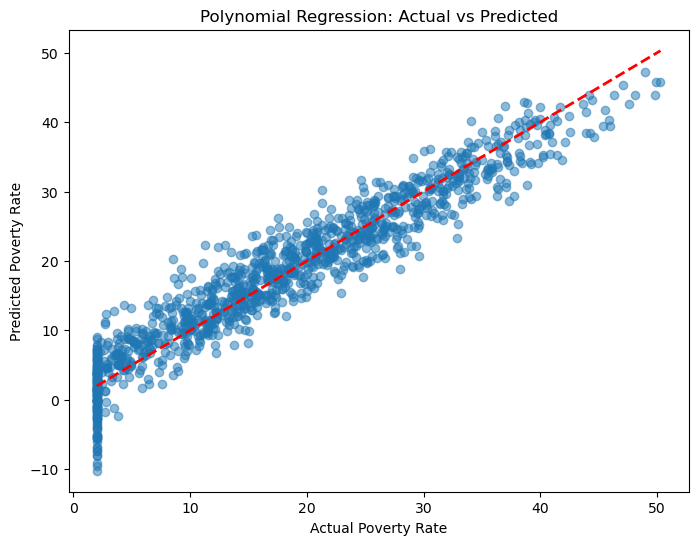

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, poly_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Poverty Rate")
plt.ylabel("Predicted Poverty Rate")
plt.title("Polynomial Regression: Actual vs Predicted")

plt.show()

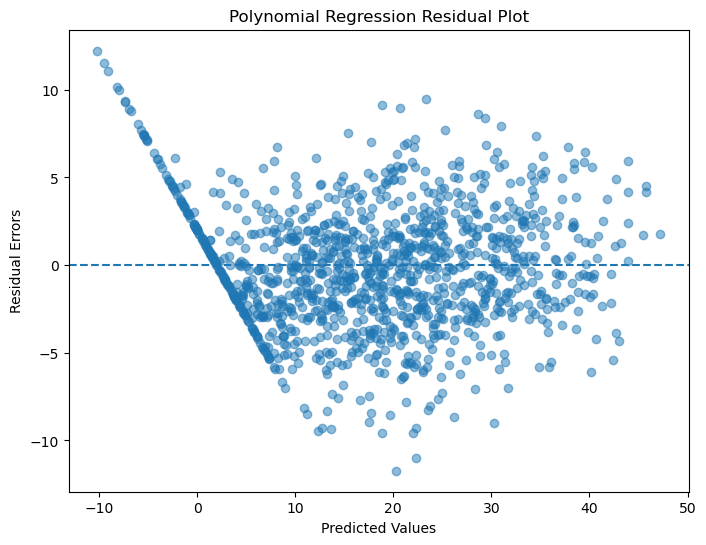

In [30]:
poly_residuals = y_test - poly_pred

plt.figure(figsize=(8,6))

plt.scatter(poly_pred, poly_residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Polynomial Regression Residual Plot")

plt.show()

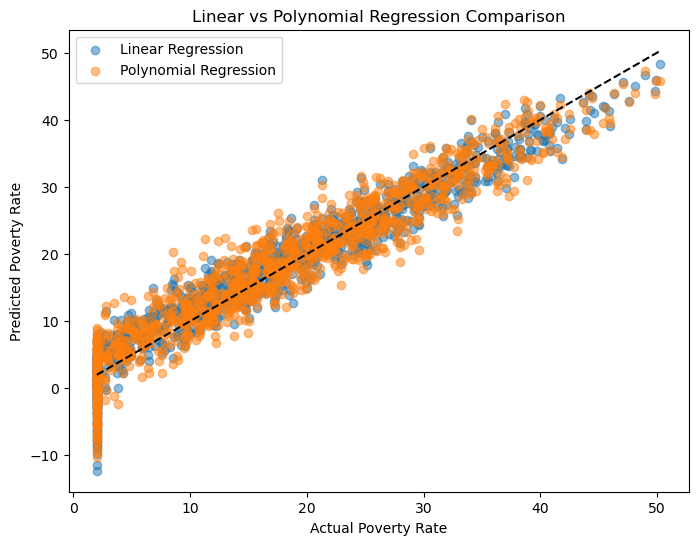

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5, label="Linear Regression")
plt.scatter(y_test, poly_pred, alpha=0.5, label="Polynomial Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

plt.xlabel("Actual Poverty Rate")
plt.ylabel("Predicted Poverty Rate")
plt.title("Linear vs Polynomial Regression Comparison")
plt.legend()

plt.show()

In [32]:
import joblib

# Save Linear Regression model
joblib.dump(model, "linear_model.pkl")

# Save Polynomial Regression model & transformer
joblib.dump(poly_model, "poly_model.pkl")
joblib.dump(poly, "poly_transformer.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']